* **nombre**: Marcos Bianchi
* **padrón**: 108921

## 1. Implemente un perceptrón simple que aprenda la función lógica AND y la función lógica OR, de 2 y de 4 entradas. Muestre la evolución del error durante el entrenamiento. Para el caso de 2 dimensiones, grafique la recta discriminadora y todos los vectores de entrada de la red.

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def plot_errors(errors: list[float], gate: str):
    xs = list(range(len(errors)))

    plt.plot(xs, errors)
    plt.title(f"Perceptron's classification error per epoch for an {gate} gate")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.xticks(xs)
    plt.grid(True)
    plt.show()


def plot_weights(ws: list[tuple[float, float, float]], gate: str):
    points = [(-1, -1), (-1, 1), (1, -1), (1, 1)]

    x_min, x_max = -1.5, 1.5
    y_min, y_max = -1.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    fig, axes = plt.subplots(1, len(ws), figsize=(6 * len(ws), 6), squeeze=False)

    for ax, (W, B) in zip(axes[0], ws):
        Z = W[0] * xx + W[1] * yy + B
        Z = np.sign(Z)

        ax.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.3, colors=["#ffcccc", "#ccccff"])
        ax.contour(xx, yy, Z, levels=[0], colors="blue")

        xs, ys = zip(*points)
        ax.scatter(xs, ys, color="red", edgecolor="black", zorder=5, label="Points")

        ax.set_title(f"weights: ({W[0].item():.2f}, {W[1].item():.2f}, {B:.2f})")

        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True)

    fig.suptitle(f"Perceptron's classification per epoch for {gate} gate")
    plt.tight_layout()
    plt.show()

$$AND(2)$$
|x1|x2|y|
|-|-|-|
|1|1|1|
|1|-1|-1|
|-1|1|-1|
|-1|-1|-1|

In [2]:
from src.perceptron import Perceptron
import numpy as np

SEED = 1234
m = Perceptron(2, seed=SEED)
X = np.array([
    [1, 1],
    [1, -1],
    [-1, 1],
    [-1, -1],
])
Y = np.array([
    [1],
    [-1],
    [-1],
    [-1],
])

ws, errors = [], []
def telemeter(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)
    ws.append((m.W.copy(), m.B))

m.train(X, Y, epoch_f=telemeter)

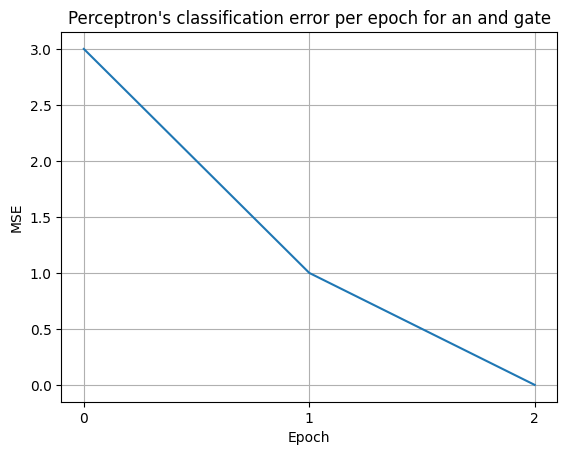

In [3]:
plot_errors(errors, "and")

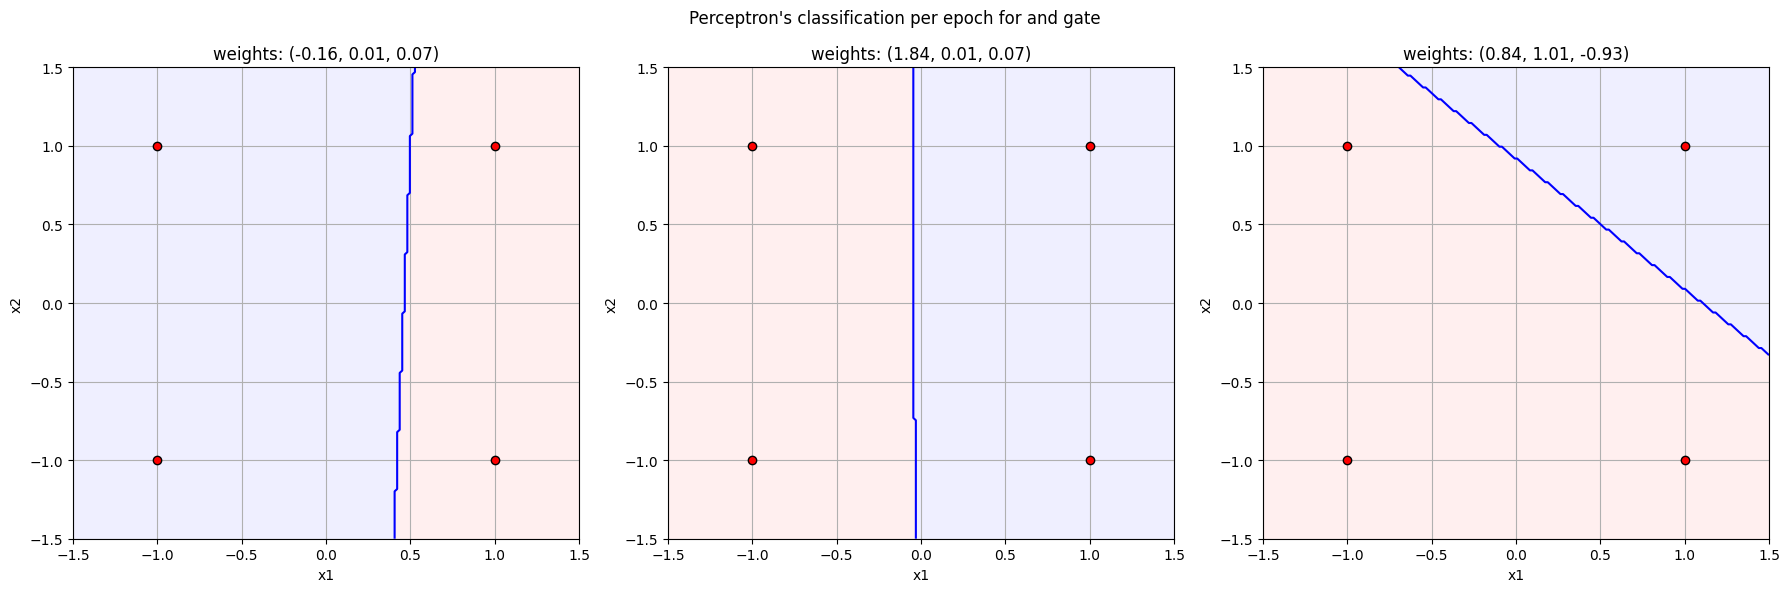

In [4]:
plot_weights(ws, "and")

$$OR(2)$$
|x1|x2|y|
|-|-|-|
|1|1|1|
|1|-1|1|
|-1|1|1|
|-1|-1|-1|

In [5]:
from src.perceptron import Perceptron
import numpy as np

SEED = 1234
m = Perceptron(2, seed=SEED)
X = np.array([
    [1, 1],
    [1, -1],
    [-1, 1],
    [-1, -1],
])
Y = np.array([
    [1],
    [1],
    [1],
    [-1],
])

ws, errors = [], []
def telemeter(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)
    ws.append((m.W.copy(), m.B))

m.train(X, Y, epoch_f=telemeter)

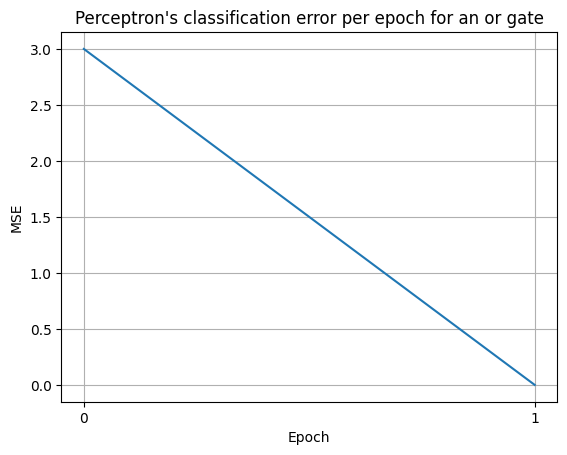

In [6]:
plot_errors(errors, "or")

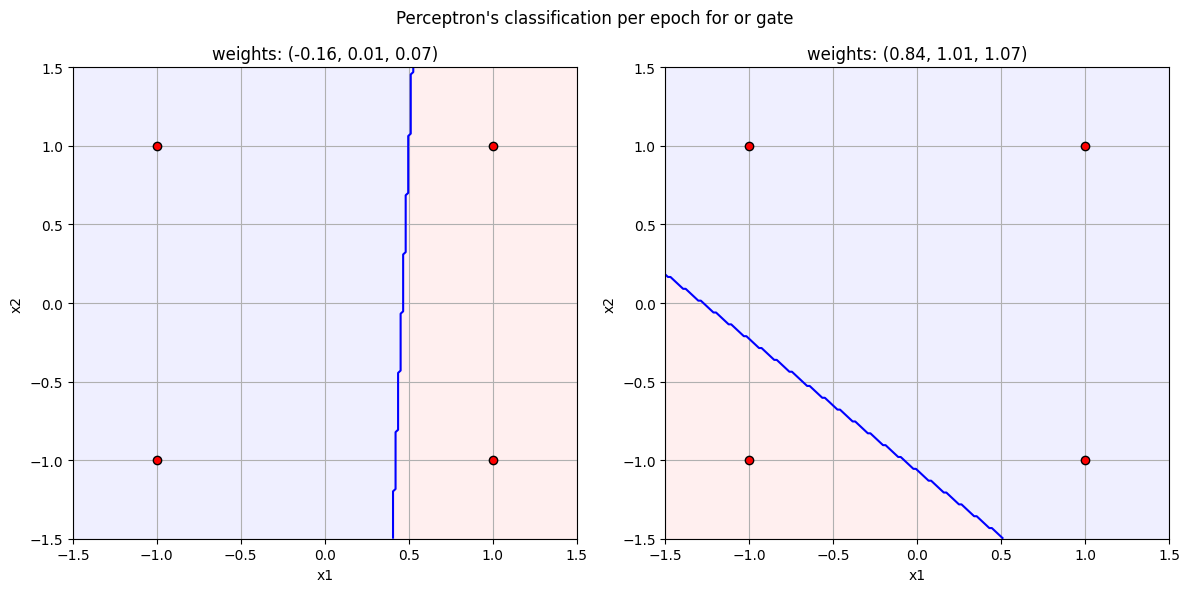

In [7]:
plot_weights(ws, "or")

$$AND(4)$$
|x1|x2|x3|x4|y|
|-|-|-|-|-|
|1|1|1|1|1|
|1|1|1|-1|-1|
|1|1|-1|1|-1|
|1|1|-1|-1|-1|
|1|-1|1|1|-1|
|1|-1|1|-1|-1|
|1|-1|-1|1|-1|
|1|-1|-1|-1|-1|
|-1|1|1|1|-1|
|-1|1|1|-1|-1|
|-1|1|-1|1|-1|
|-1|1|-1|-1|-1|
|-1|-1|1|1|-1|
|-1|-1|1|-1|-1|
|-1|-1|-1|1|-1|
|-1|-1|-1|-1|-1|

In [ ]:
from src.perceptron import Perceptron
import numpy as np

SEED = 1234
m = Perceptron(4, seed=SEED)
X = np.array([
    [1, 1],
    [1, -1],
    [-1, 1],
    [-1, -1],
])
Y = np.array([
    [1],
    [1],
    [1],
    [-1],
])

ws, errors = [], []
def telemeter(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)
    ws.append((m.W.copy(), m.B))

m.train(X, Y, epoch_f=telemeter)